In [2]:
import polars as pl
import datetime as dt

boltz_cutoff = dt.datetime(2023, 6, 1, tzinfo=dt.timezone.utc)


pdb_boltz = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_triad.boltz_rmsd.parquet"
).with_columns(
    pl.when(pl.col("pdb_date") < boltz_cutoff)
    .then(pl.lit(True))
    .otherwise(pl.lit(False))
    .alias("boltz_pre_cutoff")
)

pdb_boltz_t = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_triad.boltz_template_rmsd.parquet"
).with_columns(
    pl.when(pl.col("pdb_date") < boltz_cutoff)
    .then(pl.lit(True))
    .otherwise(pl.lit(False))
    .alias("boltz_pre_cutoff")
)

In [5]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu


def plot_rmsd_compare_boltz_templates(
    df_boltz_t: pl.DataFrame,  # Boltz run WITH templates
    df_boltz: pl.DataFrame,  # Boltz run WITHOUT templates
    rmsd_type: str,
    title: str | None = None,
    pre_col: str = "boltz_pre_cutoff",
) -> plt.Figure:
    """
    Compare a single RMSD type between Boltz (with templates) and Boltz (no templates).
    For each model we plot two boxplots (pre- and post- cutoff),
    annotate legend entries with sample counts, and print Mann–Whitney (pre vs post).
    Assumes both DataFrames share the same schema and rows (same data points).
    """
    # Column name for this RMSD
    col_boltz = f"{rmsd_type}_rmsd_boltz_4"

    # Subsets (drop nulls on the metric to keep stats/plots consistent)
    bt_pre = df_boltz_t.filter(pl.col(pre_col), pl.col(col_boltz).is_not_null())
    bt_post = df_boltz_t.filter(~pl.col(pre_col), pl.col(col_boltz).is_not_null())
    b_pre = df_boltz.filter(pl.col(pre_col), pl.col(col_boltz).is_not_null())
    b_post = df_boltz.filter(~pl.col(pre_col), pl.col(col_boltz).is_not_null())

    n_bt_pre, n_bt_post = bt_pre.height, bt_post.height
    n_b_pre, n_b_post = b_pre.height, b_post.height

    # Values for boxplots
    bt_pre_vals = bt_pre.select(pl.col(col_boltz)).to_numpy().flatten()
    bt_post_vals = bt_post.select(pl.col(col_boltz)).to_numpy().flatten()
    b_pre_vals = b_pre.select(pl.col(col_boltz)).to_numpy().flatten()
    b_post_vals = b_post.select(pl.col(col_boltz)).to_numpy().flatten()

    # Simple stats: pre vs post within each model
    def mwu(name, a, b):
        if len(a) > 0 and len(b) > 0:
            U, p = mannwhitneyu(a, b, alternative="less", method="auto")
            print(
                f"{name} Mann–Whitney U (pre < post): U={U:.3f}, p={p:.3g}, n_pre={len(a)}, n_post={len(b)}"
            )
        else:
            print(f"{name} Mann–Whitney skipped due to empty group(s)")

    mwu("Boltz+Templates", bt_pre_vals, bt_post_vals)
    mwu("Boltz", b_pre_vals, b_post_vals)

    # Plot
    x = np.array([0, 1])  # 0: Boltz+T, 1: Boltz
    width = 0.35
    fig, ax = plt.subplots(figsize=(7.5, 5))

    # Colors
    pre_color = "tab:blue"
    post_color = "tab:orange"

    # Boltz + Templates
    ax.boxplot(
        bt_pre_vals,
        positions=[x[0] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor=pre_color, edgecolor="black"),
        whiskerprops=dict(color=pre_color),
        capprops=dict(color=pre_color),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor=pre_color),
    )
    ax.boxplot(
        bt_post_vals,
        positions=[x[0] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor=post_color, edgecolor="black"),
        whiskerprops=dict(color=post_color),
        capprops=dict(color=post_color),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor=post_color),
    )

    # Boltz (no templates)
    ax.boxplot(
        b_pre_vals,
        positions=[x[1] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor=pre_color, edgecolor="black"),
        whiskerprops=dict(color=pre_color),
        capprops=dict(color=pre_color),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor=pre_color),
    )
    ax.boxplot(
        b_post_vals,
        positions=[x[1] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor=post_color, edgecolor="black"),
        whiskerprops=dict(color=post_color),
        capprops=dict(color=post_color),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor=post_color),
    )

    # Labels
    ax.set_xticks(x)
    ax.set_xticklabels(["Boltz (+templates)", "Boltz (no templates)"])
    ax.set_ylabel(f"{rmsd_type.upper()} RMSD (Å)")
    if title:
        ax.set_title(title)

    legend_handles = [
        Patch(
            facecolor=pre_color,
            edgecolor="black",
            label=f"+Templates pre (n={n_bt_pre})",
        ),
        Patch(
            facecolor=post_color,
            edgecolor="black",
            label=f"+Templates post (n={n_bt_post})",
        ),
        Patch(
            facecolor=pre_color,
            edgecolor="black",
            label=f"No templates pre (n={n_b_pre})",
        ),
        Patch(
            facecolor=post_color,
            edgecolor="black",
            label=f"No templates post (n={n_b_post})",
        ),
    ]
    ax.legend(handles=legend_handles, loc="upper right")

    plt.tight_layout()
    return fig

Boltz+Templates Mann–Whitney U (pre < post): U=40.000, p=1.05e-06, n_pre=95, n_post=10
Boltz Mann–Whitney U (pre < post): U=20.000, p=3.5e-07, n_pre=95, n_post=10


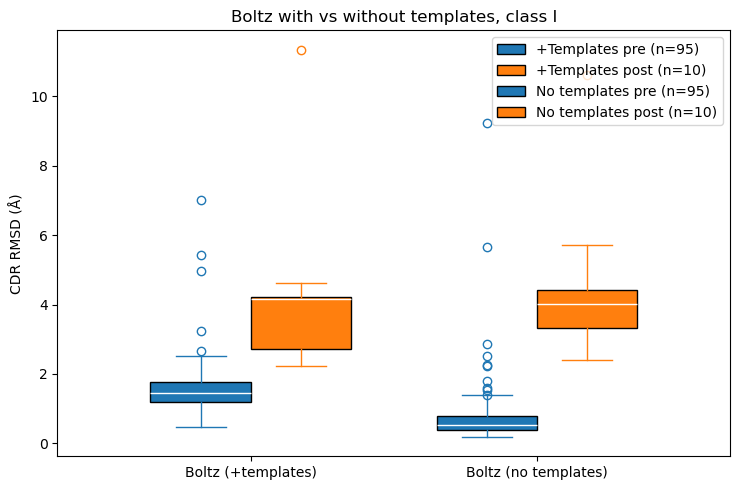

In [19]:
_ = plot_rmsd_compare_boltz_templates(
    pdb_boltz_t.filter(pl.col("mhc_class") == "I"),
    pdb_boltz.filter(pl.col("mhc_class") == "I"),
    "cdr",
    title="Boltz with vs without templates, class I"
)

Boltz+Templates Mann–Whitney U (pre < post): U=51.000, p=0.00988, n_pre=41, n_post=6
Boltz Mann–Whitney U (pre < post): U=65.000, p=0.033, n_pre=41, n_post=6


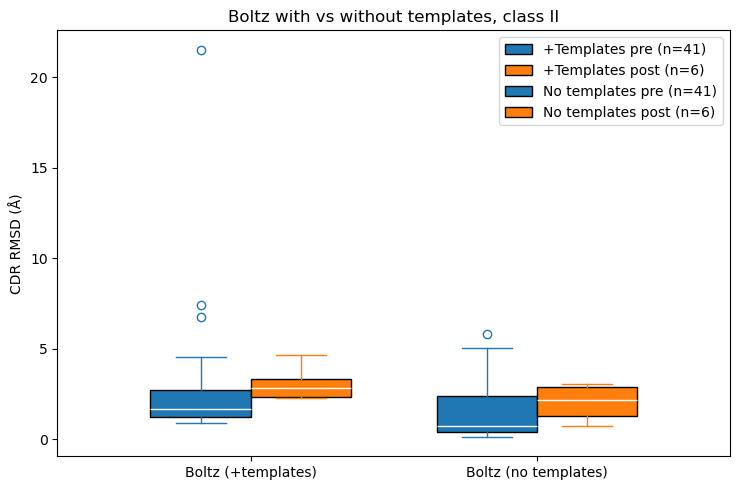

In [20]:
_ = plot_rmsd_compare_boltz_templates(
    pdb_boltz_t.filter(pl.col("mhc_class") == "II"),
    pdb_boltz.filter(pl.col("mhc_class") == "II"),
    "cdr",
    title="Boltz with vs without templates, class II"
)

In [18]:
pdb_boltz_t.sort(by="cdr_rmsd_boltz_4", descending=True).select("pdb", "cdr_rmsd_boltz_4", "job_name")

pdb,cdr_rmsd_boltz_4,job_name
str,f64,str
"""3o6f""",21.514457,"""96b9104ef308fef91dbb9bea88fb6c…"
"""8f5a""",11.347913,"""2189f00834a936e6efea39cd61ca41…"
"""4grl""",7.439391,"""0719f50275543d7d2308a911619e78…"
"""5e6i""",7.016921,"""e9832c8ad0c064a3eab06b9646d44d…"
"""4may""",6.728566,"""3b589623079e33e85fb4c499ecfef2…"
…,…,…
"""5ivx""",0.860561,"""1d3c2889f46ea790c30cf25cbca3dd…"
"""5c0b""",0.857411,"""3e76347df6b364d2e2069393b5e41f…"
"""7n1e""",0.840181,"""66588fb6f41c42796a59e21f801dcc…"
